# Первые эксперименты по обучению nanoGPT со спарсными активациями

Этот ноутбук собирает компактный пайплайн первого этапа экспериментов для проекта про обучение трансформеров со спарсными активациями и длинным контекстом.

Тут сделали следующее:

1. подготовили маленький датасет для посимвольного языкового моделирования,
2. обучили dense-бейзлайн трансформера в течение небольшого числа шагов,
3. обучили sparse-вариант, где в FFN активны только top-k каналов,
4. повторили сравнение в более тяжелой конфигурации с длинным контекстом,
5. сравнили loss, throughput и потребление памяти.

In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import requests
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm.auto import tqdm

device = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.manual_seed(42)
device

'cuda'

## Данные

Для первых экспериментов используется корпус достаточно большой датасет Tiny Shakespeare, как быстрый датасет для экспериментов по языковому моделированию

In [3]:
data_dir = Path('data')
data_dir.mkdir(exist_ok=True)
text_path = data_dir / 'tiny_shakespeare.txt'

if not text_path.exists():
    text = requests.get('https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt', timeout=30).text
    text_path.write_text(text)

text = text_path.read_text()
chars = sorted(list(set(text)))
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for ch, i in stoi.items()}
encode = lambda s: [stoi[c] for c in s]
decode = lambda ids: ''.join(itos[i] for i in ids)

data = torch.tensor(encode(text), dtype=torch.long)
split = int(0.9 * len(data))
train_data = data[:split]
val_data = data[split:]

len(text), len(chars), train_data.shape, val_data.shape

(1115394, 65, torch.Size([1003854]), torch.Size([111540]))

## Семейство моделей

В качестве бейзлайна возьмем компактный GPT-подобный трансформер. Sparse-вариант отличается только FFN-блоком: после первой линейной проекции для каждого токена активными остаются только top-k каналов по модулю активации. Это простое первое приближение к спарсификации активаций. Реализация специально сделана через dense-операции PyTorch, чтобы на первом этапе отделить эффект самой идеи от kernel-level оптимизации.

In [4]:
dropout = 0.1
vocab_size = len(chars)
ffn_mult = 4
sparsity_ratio = 0.75

class CausalSelfAttention(nn.Module):
    def __init__(self, n_embd, n_head):
        super().__init__()
        self.n_head = n_head
        self.head_dim = n_embd // n_head
        self.qkv = nn.Linear(n_embd, 3 * n_embd)
        self.proj = nn.Linear(n_embd, n_embd)
        self.resid_dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, T, C = x.shape
        q, k, v = self.qkv(x).chunk(3, dim=-1)
        q = q.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        y = F.scaled_dot_product_attention(q, k, v, is_causal=True, dropout_p=dropout if self.training else 0.0)
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        y = self.resid_dropout(self.proj(y))
        return y

class DenseMLP(nn.Module):
    def __init__(self, n_embd):
        super().__init__()
        hidden = ffn_mult * n_embd
        self.fc = nn.Linear(n_embd, hidden)
        self.proj = nn.Linear(hidden, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.fc(x)
        x = F.gelu(x)
        x = self.proj(x)
        x = self.dropout(x)
        return x

class SparseMLP(nn.Module):
    def __init__(self, n_embd, sparsity_ratio):
        super().__init__()
        hidden = ffn_mult * n_embd
        self.keep = max(1, int(hidden * (1 - sparsity_ratio)))
        self.fc = nn.Linear(n_embd, hidden)
        self.proj = nn.Linear(hidden, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.fc(x)
        x = F.gelu(x)
        _, indices = torch.topk(x.abs(), k=self.keep, dim=-1)
        mask = torch.zeros_like(x)
        mask.scatter_(-1, indices, 1.0)
        x = x * mask
        x = self.proj(x)
        x = self.dropout(x)
        return x

class Block(nn.Module):
    def __init__(self, n_embd, n_head, sparse=False, sparsity_ratio=0.0):
        super().__init__()
        self.ln1 = nn.LayerNorm(n_embd)
        self.attn = CausalSelfAttention(n_embd, n_head)
        self.ln2 = nn.LayerNorm(n_embd)
        self.mlp = SparseMLP(n_embd, sparsity_ratio) if sparse else DenseMLP(n_embd)

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.mlp(self.ln2(x))
        return x

class TinyGPT(nn.Module):
    def __init__(self, block_size, n_embd, n_head, n_layer, sparse=False, sparsity_ratio=0.0):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, n_embd)
        self.pos_emb = nn.Embedding(block_size, n_embd)
        self.blocks = nn.ModuleList([Block(n_embd, n_head, sparse=sparse, sparsity_ratio=sparsity_ratio) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd)
        self.head = nn.Linear(n_embd, vocab_size, bias=False)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        pos = torch.arange(T, device=idx.device)
        x = self.token_emb(idx) + self.pos_emb(pos)[None, :, :]
        for block in self.blocks:
            x = block(x)
        x = self.ln_f(x)
        logits = self.head(x)
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
        return logits, loss

## Эксперимент 1: short-context бейзлайн

Проврерим, остается ли sparse-приближение вообще обучаемым в умеренной конфигурации. Зададим тем самым чистый бейзлайн перед переходом к более тяжелым настройкам.

In [5]:
experiment_name = 'short_context'
batch_size = 32
block_size = 128
n_embd = 192
n_head = 6
n_layer = 4
steps = 500
eval_interval = 20
lr = 3e-4

results = []

for name, sparse_flag in [('dense', False), ('sparse', True)]:
    model = TinyGPT(block_size=block_size, n_embd=n_embd, n_head=n_head, n_layer=n_layer, sparse=sparse_flag, sparsity_ratio=sparsity_ratio).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    if device == 'cuda':
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()
    start = time.time()
    progress = tqdm(range(1, steps + 1), desc=f'{experiment_name}:{name}', leave=False)
    for step in progress:
        ix = torch.randint(len(train_data) - block_size - 1, (batch_size,))
        xb = torch.stack([train_data[i:i + block_size] for i in ix]).to(device)
        yb = torch.stack([train_data[i + 1:i + block_size + 1] for i in ix]).to(device)
        model.train()
        optimizer.zero_grad(set_to_none=True)
        _, loss = model(xb, yb)
        loss.backward()
        optimizer.step()

        if step % eval_interval == 0 or step == 1:
            model.eval()
            with torch.no_grad():
                ix_val = torch.randint(len(val_data) - block_size - 1, (batch_size,))
                xval = torch.stack([val_data[i:i + block_size] for i in ix_val]).to(device)
                yval = torch.stack([val_data[i + 1:i + block_size + 1] for i in ix_val]).to(device)
                _, val_loss = model(xval, yval)
            progress.set_postfix(train_loss=f'{loss.item():.3f}', val_loss=f'{val_loss.item():.3f}')
            results.append({
                'experiment': experiment_name,
                'model': name,
                'step': step,
                'train_loss': loss.item(),
                'val_loss': val_loss.item()
            })
    if device == 'cuda':
        torch.cuda.synchronize()
    elapsed = time.time() - start
    peak_memory_mb = torch.cuda.max_memory_allocated() / 1024**2 if device == 'cuda' else float('nan')
    tokens_processed = steps * batch_size * block_size
    results.append({
        'experiment': experiment_name,
        'model': name,
        'step': 'summary',
        'train_loss': float('nan'),
        'val_loss': float('nan'),
        'elapsed_sec': elapsed,
        'tokens_per_sec': tokens_processed / elapsed,
        'peak_memory_mb': peak_memory_mb
    })

results_df = pd.DataFrame(results)
results_df

short_context:dense:   0%|          | 0/500 [00:00<?, ?it/s]

short_context:sparse:   0%|          | 0/500 [00:00<?, ?it/s]

,experiment,model,step,train_loss,val_loss,elapsed_sec,tokens_per_sec,peak_memory_mb
0,short_context,dense,1,4.301603,4.095449,NaN,NaN,NaN
1,short_context,dense,20,3.019353,3.066434,NaN,NaN,NaN
2,short_context,dense,40,2.805069,2.728816,NaN,NaN,NaN
3,short_context,dense,60,2.688743,2.625922,NaN,NaN,NaN
4,short_context,dense,80,2.578394,2.594366,NaN,NaN,NaN
5,short_context,dense,100,2.562107,2.571986,NaN,NaN,NaN
6,short_context,dense,120,2.568209,2.561136,NaN,NaN,NaN
7,short_context,dense,140,2.537448,2.494672,NaN,NaN,NaN
8,short_context,dense,160,2.493407,2.536579,NaN,NaN,NaN
9,short_context,dense,180,2.481992,2.491445,NaN,NaN,NaN


Результат short-context эксперимента уже выглядит достаточно убедительно. Обе модели обучаются стабильно на протяжении 500 итераций и приходят к сопоставимому уровню качества. Dense-бейзлайн к концу эксперимента достигает validation loss около 2.24, тогда как sparse-вариант показывает validation loss около 2.35. То есть даже при довольно агрессивной спарсификации модель сохраняет обучаемость и не разваливается по качеству. При этом sparse PyTorch-прокси по-прежнему заметно проигрывает dense-бейзлайну с точки зрения системной эффективности: throughput снижается примерно с 180.8k до 131.4k tokens/sec, а peak memory увеличивается примерно с 262.7 MB до 314.0 MB. Это ожидаемый результат для наивной dense-backed реализации через torch: такой прототип мы сделали для проверки самой идеи спарсификации на уровне обучения, а не для получения немедленного ускорения. Именно поэтому следующий этап проекта естественно связан с разработкой специализированных sparse kernels, которые должны превратить модельную спарсность в реальный выигрыш по времени и памяти

## Эксперимент 2: более тяжелая longer-context конфигурация

Повторение сравним в более тяжелой конфигурации с большим контекстом, большим hidden size и большим числом слоев. Такая постановка все еще подъемна на одной T4. Цель здесь - это проверить, сохраняется ли тот же качественный паттерн в заметно более тяжелом режиме обучения.

In [ ]:
experiment_name = 'longer_context'
batch_size = 24
block_size = 256
n_embd = 256
n_head = 8
n_layer = 6
steps = 500
eval_interval = 20
lr = 3e-4

for name, sparse_flag in [('dense', False), ('sparse', True)]:
    model = TinyGPT(block_size=block_size, n_embd=n_embd, n_head=n_head, n_layer=n_layer, sparse=sparse_flag, sparsity_ratio=sparsity_ratio).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    if device == 'cuda':
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()
    start = time.time()
    progress = tqdm(range(1, steps + 1), desc=f'{experiment_name}:{name}', leave=False)
    for step in progress:
        ix = torch.randint(len(train_data) - block_size - 1, (batch_size,))
        xb = torch.stack([train_data[i:i + block_size] for i in ix]).to(device)
        yb = torch.stack([train_data[i + 1:i + block_size + 1] for i in ix]).to(device)
        model.train()
        optimizer.zero_grad(set_to_none=True)
        _, loss = model(xb, yb)
        loss.backward()
        optimizer.step()

        if step % eval_interval == 0 or step == 1:
            model.eval()
            with torch.no_grad():
                ix_val = torch.randint(len(val_data) - block_size - 1, (batch_size,))
                xval = torch.stack([val_data[i:i + block_size] for i in ix_val]).to(device)
                yval = torch.stack([val_data[i + 1:i + block_size + 1] for i in ix_val]).to(device)
                _, val_loss = model(xval, yval)
            progress.set_postfix(train_loss=f'{loss.item():.3f}', val_loss=f'{val_loss.item():.3f}')
            results.append({
                'experiment': experiment_name,
                'model': name,
                'step': step,
                'train_loss': loss.item(),
                'val_loss': val_loss.item()
            })
    if device == 'cuda':
        torch.cuda.synchronize()
    elapsed = time.time() - start
    peak_memory_mb = torch.cuda.max_memory_allocated() / 1024**2 if device == 'cuda' else float('nan')
    tokens_processed = steps * batch_size * block_size
    results.append({
        'experiment': experiment_name,
        'model': name,
        'step': 'summary',
        'train_loss': float('nan'),
        'val_loss': float('nan'),
        'elapsed_sec': elapsed,
        'tokens_per_sec': tokens_processed / elapsed,
        'peak_memory_mb': peak_memory_mb
    })

results_df = pd.DataFrame(results)
results_df

longer_context:dense:   0%|          | 0/500 [00:00<?, ?it/s]

longer_context:sparse:   0%|          | 0/500 [00:00<?, ?it/s]

,experiment,model,step,train_loss,val_loss,elapsed_sec,tokens_per_sec,peak_memory_mb
0,short_context,dense,1,4.301603,4.095449,NaN,NaN,NaN
1,short_context,dense,20,3.019353,3.066434,NaN,NaN,NaN
2,short_context,dense,40,2.805069,2.728816,NaN,NaN,NaN
3,short_context,dense,60,2.688743,2.625922,NaN,NaN,NaN
4,short_context,dense,80,2.578394,2.594366,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
103,longer_context,sparse,440,2.331170,2.358510,NaN,NaN,NaN
104,longer_context,sparse,460,2.339086,2.315501,NaN,NaN,NaN
105,longer_context,sparse,480,2.341438,2.270237,NaN,NaN,NaN
106,longer_context,sparse,500,2.221880,2.264990,NaN,NaN,NaN


In [8]:
from IPython.display import display

with pd.option_context('display.max_rows', None):
    display(results_df)

,experiment,model,step,train_loss,val_loss,elapsed_sec,tokens_per_sec,peak_memory_mb
0,short_context,dense,1,4.301603,4.095449,NaN,NaN,NaN
1,short_context,dense,20,3.019353,3.066434,NaN,NaN,NaN
2,short_context,dense,40,2.805069,2.728816,NaN,NaN,NaN
3,short_context,dense,60,2.688743,2.625922,NaN,NaN,NaN
4,short_context,dense,80,2.578394,2.594366,NaN,NaN,NaN
5,short_context,dense,100,2.562107,2.571986,NaN,NaN,NaN
6,short_context,dense,120,2.568209,2.561136,NaN,NaN,NaN
7,short_context,dense,140,2.537448,2.494672,NaN,NaN,NaN
8,short_context,dense,160,2.493407,2.536579,NaN,NaN,NaN
9,short_context,dense,180,2.481992,2.491445,NaN,NaN,NaN


## Графики обучения

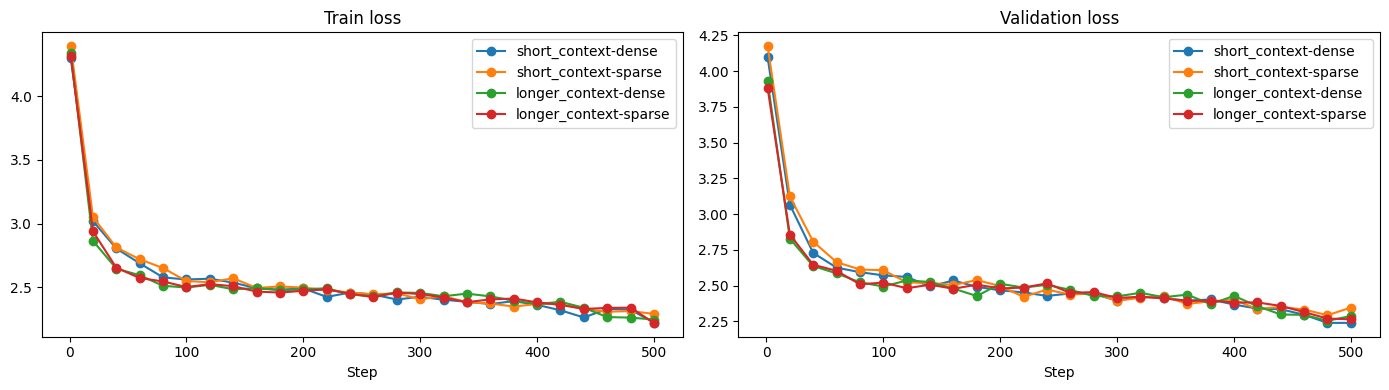

In [9]:
curve_df = results_df[results_df['step'] != 'summary'].copy()
curve_df['step'] = curve_df['step'].astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for experiment in curve_df['experiment'].unique():
    subset = curve_df[curve_df['experiment'] == experiment]
    for model_name in subset['model'].unique():
        part = subset[subset['model'] == model_name]
        axes[0].plot(part['step'], part['train_loss'], marker='o', label=f'{experiment}-{model_name}')
        axes[1].plot(part['step'], part['val_loss'], marker='o', label=f'{experiment}-{model_name}')
axes[0].set_title('Train loss')
axes[1].set_title('Validation loss')
axes[0].set_xlabel('Step')
axes[1].set_xlabel('Step')
axes[0].legend()
axes[1].legend()
plt.tight_layout()
plt.show()

Первый вопрос состоит в том, остается ли sparse-вариант обучаемым и в легкой, и в более тяжелой конфигурации. По кривым видно, что ответ положительный: в обоих экспериментах sparse-модель идет близко к dense-бейзлайну и приходит к очень похожему финальному validation loss.

## Сравнение эффективности

In [10]:
summary_df = results_df[results_df['step'] == 'summary'][['experiment', 'model', 'elapsed_sec', 'tokens_per_sec', 'peak_memory_mb']].reset_index(drop=True)
summary_df

,experiment,model,elapsed_sec,tokens_per_sec,peak_memory_mb
0,short_context,dense,11.329089,180773.583235,262.684570
1,short_context,sparse,15.580575,131445.724568,313.976562
2,longer_context,dense,38.492493,79807.768460,721.560547
3,longer_context,sparse,51.472898,59681.893447,872.993164


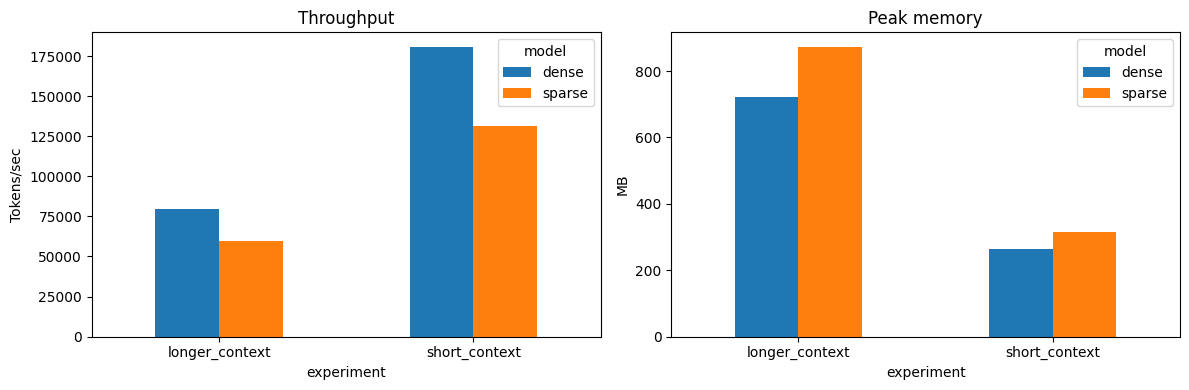

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
throughput_pivot = summary_df.pivot(index='experiment', columns='model', values='tokens_per_sec')
memory_pivot = summary_df.pivot(index='experiment', columns='model', values='peak_memory_mb')
throughput_pivot.plot(kind='bar', ax=axes[0], rot=0, title='Throughput')
axes[0].set_ylabel('Tokens/sec')
memory_pivot.plot(kind='bar', ax=axes[1], rot=0, title='Peak memory')
axes[1].set_ylabel('MB')
plt.tight_layout()
plt.show()

Второй вопрос состоит в том, меняет ли спарсификация время работы и потребление памяти еще до появления кастомных kernels. Ответ по результатам первого этапа тоже однозначный: при vanilla PyTorch masking спарсификация делает обучение и медленнее, и тяжелее по памяти в обеих конфигурациях. Но это все равно полезный результат, потому что он отделяет жизнеспособность самой идеи от системной эффективности и задает конкретную цель для будущей kernel-оптимизации

## Интерпретация

В short-context эксперименте dense-модель достигла validation loss около 2.24, а sparse-модель около 2.35. В более тяжелом longer-context эксперименте dense-модель достигла примерно 2.29, а sparse-модель примерно 2.26. Это означает, что sparse-приближение остается обучаемым в обеих конфигурациях и в более тяжелом режиме даже выходит на качество, сопоставимое с dense-бейзлайном. При этом видно, что в short-context режиме dense-вариант пока обучается немного лучше, тогда как в longer-context режиме разрыв практически исчезает.

С системной точки зрения sparse-прокси по-прежнему стабильно хуже dense-бейзлайна. В short-context эксперименте throughput снизился примерно с 180.8k до 131.4k tokens/sec, а peak memory вырос примерно с 262.7 MB до 314.0 MB. В longer-context эксперименте throughput снизился примерно с 79.8k до 59.7k tokens/sec, а peak memory вырос примерно с 721.6 MB до 873.0 MB. Наивная реализация masking через dense PyTorch не превращает структурную спарсность в реальный выигрыш по времени и памяти.

Таким образом, первый этап проекта дает сильный и честный вывод: спарсификация на уровне обучения сохраняет качество, но для получения практической эффективности необходимы специализированные sparse kernels для forward и backward pass.

## Итог первых экспериментов

На первом этапе проекта был реализован компактный GPT-подобный стенд обучения, в котором сравнивались dense FFN-бейзлайн и sparse-activation FFN-вариант на основе top-k выбора каналов. Модели были исследованы в двух режимах: short-context бейзлайн и более тяжелая longer-context конфигурация. В обоих случаях sparse-модель сохранила обучаемость и сошлась к качеству, близкому к dense-бейзлайну: в short-context режиме sparse-вариант немного уступил dense-модели, а в longer-context режиме показал практически сопоставимый результат. Однако наивная PyTorch-реализация спарсификации оказалась стабильно медленнее и требовала больше peak memory, чем dense-бейзлайн. Это показывает, что одной только спарсификации на уровне модели недостаточно для системного выигрыша и что следующий этап проекта должен быть связан с разработкой кастомных kernels для эффективного sparse forward/backward, а затем с более масштабными long-context экспериментами.